In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and prepare the data
df = pd.read_csv("filtered_data.csv") 
X = df.drop(columns=["readmitted"]).values.astype(float)
y = df["readmitted"].values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. Convert to PyTorch tensors and create DataLoaders
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# 3. Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)




# 4. Instantiate model, loss, optimizer
device = torch.device("cuda")  # or "cuda" if GPU is available
model = SimpleNN(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 5. Training loop
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch:02d}/{num_epochs}, Loss: {epoch_loss:.4f}")

# 6. Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        predicted = (preds > 0.5).float()
        total += yb.size(0)
        correct += (predicted == yb).sum().item()
accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 01/30, Loss: 0.4410
Epoch 02/30, Loss: 0.4235
Epoch 03/30, Loss: 0.4213
Epoch 04/30, Loss: 0.4192
Epoch 05/30, Loss: 0.4180
Epoch 06/30, Loss: 0.4172
Epoch 07/30, Loss: 0.4174
Epoch 08/30, Loss: 0.4158
Epoch 09/30, Loss: 0.4154
Epoch 10/30, Loss: 0.4147
Epoch 11/30, Loss: 0.4141
Epoch 12/30, Loss: 0.4140
Epoch 13/30, Loss: 0.4138
Epoch 14/30, Loss: 0.4126
Epoch 15/30, Loss: 0.4136
Epoch 16/30, Loss: 0.4134
Epoch 17/30, Loss: 0.4123
Epoch 18/30, Loss: 0.4128
Epoch 19/30, Loss: 0.4121
Epoch 20/30, Loss: 0.4115
Epoch 21/30, Loss: 0.4112
Epoch 22/30, Loss: 0.4109
Epoch 23/30, Loss: 0.4105
Epoch 24/30, Loss: 0.4096
Epoch 25/30, Loss: 0.4096
Epoch 26/30, Loss: 0.4097
Epoch 27/30, Loss: 0.4094
Epoch 28/30, Loss: 0.4089
Epoch 29/30, Loss: 0.4084
Epoch 30/30, Loss: 0.4083
Test Accuracy: 0.8315


In [48]:
# Load and preprocess filtered data
filtered_df = pd.read_csv("filtered_data.csv")
X_filtered = filtered_df.drop(columns=["readmitted"]).values.astype(float)
y_filtered = filtered_df["readmitted"].values.astype(float)

X_filtered_scaled = scaler.transform(X_filtered)

X_filtered_tensor = torch.tensor(X_filtered_scaled, dtype=torch.float32)
y_filtered_tensor = torch.tensor(y_filtered, dtype=torch.float32).unsqueeze(1)

filtered_ds = TensorDataset(X_filtered_tensor, y_filtered_tensor)
filtered_loader = DataLoader(filtered_ds, batch_size=64, shuffle=False)

# Inference
model.eval()
correct_filtered = 0
total_filtered = 0
with torch.no_grad():
    for xb, yb in filtered_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        predicted = (preds > 0.5).float()
        total_filtered += yb.size(0)
        correct_filtered += (predicted == yb).sum().item()

filtered_accuracy = correct_filtered / total_filtered
print(f"Filtered Dataset Accuracy: {filtered_accuracy:.4f}")


Filtered Dataset Accuracy: 0.8387


Accuracy : 0.8315
Precision: 0.8366
Recall   : 0.9887
F1 Score : 0.9063


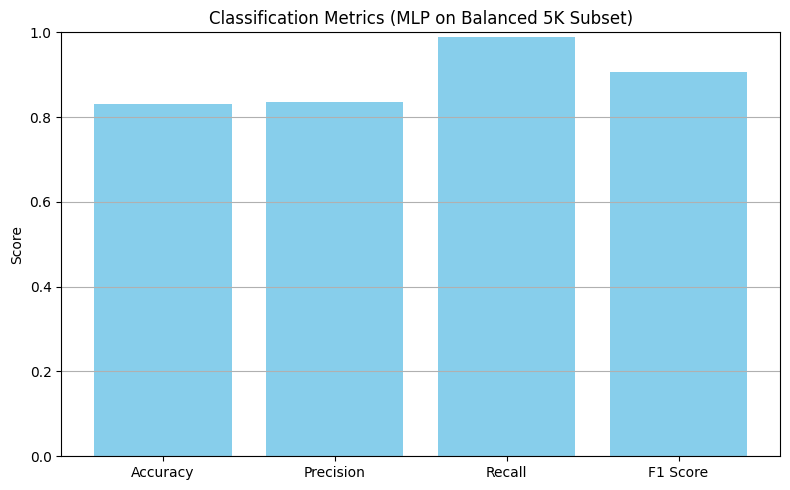

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Put model in evaluation mode and move to CPU
model.eval()
model.cpu()

# 2. Predict on the test set
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb)
        predicted = (preds > 0.5).float()
        all_preds.append(predicted.numpy())
        all_labels.append(yb.numpy())

# 3. Flatten predictions and true labels
y_pred = np.vstack(all_preds).flatten()
y_true = np.vstack(all_labels).flatten()

# 4. Compute metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

# 5. Print them
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# 6. Plot bar chart
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color='skyblue')
plt.ylim(0, 1)
plt.title('Classification Metrics (MLP on Balanced 5K Subset)')
plt.ylabel('Score')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [40]:
df=pd.read_csv("mi_4000_high_1000_low.csv")
df['readmitted'].value_counts()

readmitted
1    3154
0    1846
Name: count, dtype: int64

In [10]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Load
df = pd.read_csv('5k_l2_mi_half_selected_balanced_subset.csv')

# 2. Define target and features
target = 'readmitted'
features = [c for c in df.columns if c != target]

# 3. Correct categorical feature names
cat_features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'diag_1',
    'max_glu_serum',
    'A1Cresult',
    'insulin',
    'change',
    'diabetesMed'
]

# 4. Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target],
    test_size=0.2,
    random_state=42,
    stratify=df[target]
)

# 5. Initialize CatBoost
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.001,
    depth=9,
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

# 6. Fit with early stopping
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

# 7. Evaluate
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Show importances
print("\nFeature Importances:")
print(model.get_feature_importance(prettified=True))


0:	learn: 0.7715000	test: 0.7460000	best: 0.7460000 (0)	total: 22.5ms	remaining: 22.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.776
bestIteration = 26

Shrink model to first 27 iterations.
Test Accuracy: 0.776

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.60      0.64       327
           1       0.82      0.86      0.84       673

    accuracy                           0.78      1000
   macro avg       0.75      0.73      0.74      1000
weighted avg       0.77      0.78      0.77      1000


Feature Importances:
                  Feature Id  Importances
0           number_inpatient    60.001336
1   discharge_disposition_id    15.653194
2                  A1Cresult     4.246324
3           number_emergency     3.755549
4        admission_source_id     3.426451
5                        age     2.538626
6          admission_type_id     2.364948
7                       race     2.203496
8          

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("5k_l2_mi_half_selected_balanced_subset.csv")

# Split features and target
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest with tuned parameters
rf_clf = RandomForestClassifier(
    n_estimators=2000,
    max_depth=100,
    min_samples_split=2,
    max_features='sqrt',
    random_state=42
)
rf_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_clf.predict(X_test)

# Compute all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# Print all results
print(f"Tuned Random Forest Test Accuracy : {accuracy:.4f}")
print(f"Precision                        : {precision:.4f}")
print(f"Recall                           : {recall:.4f}")
print(f"F1 Score                         : {f1:.4f}")


Tuned Random Forest Test Accuracy : 0.7830
Precision                        : 0.8183
Recall                           : 0.8812
F1 Score                         : 0.8486


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("5k_l2_mi_half_selected_balanced_subset.csv")

# Split features and target
X = df.drop(columns=["readmitted"])
y = df["readmitted"]

# Standardize features (essential for SVMs with RBF)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Tuned SVM: C balances margin size vs misclassification, gamma controls kernel sensitivity
svm_clf = SVC(
    kernel='rbf',
    C=20,              # Higher C → less margin, lower bias
    gamma=0.01,        # Smaller gamma → smoother decision boundary
    probability=False,
    random_state=42
)
svm_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_clf.predict(X_test)

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

# Print results
print(f"Tuned SVM Test Accuracy : {accuracy:.4f}")
print(f"Precision               : {precision:.4f}")
print(f"Recall                  : {recall:.4f}")
print(f"F1 Score                : {f1:.4f}")


Tuned SVM Test Accuracy : 0.7630
Precision               : 0.8065
Recall                  : 0.8638
F1 Score                : 0.8341
